In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"D:\Python_ML_projects\Website_Analysis_Project_9\data-export (1).csv")
df

,# ----------------------------------------,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,Session primary channel group (Default channel...,Date + hour (YYYYMMDDHH),Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
1,Direct,2024041623,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402
2,Organic Social,2024041719,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
3,Direct,2024041723,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069
4,Organic Social,2024041718,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044
...,...,...,...,...,...,...,...,...,...,...
3178,Unassigned,2024042806,0,1,0,0,0,2,0,2
3179,Unassigned,2024043005,0,1,0,0,0,2,0,2
3180,Unassigned,2024043006,0,1,0,0,0,2,0,2
3181,Unassigned,2024050105,0,1,0,0,0,2,0,2


In [3]:
df.columns = df.iloc[0]
df.head()

,Session primary channel group (Default channel group),Date + hour (YYYYMMDDHH),Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
0,Session primary channel group (Default channel...,Date + hour (YYYYMMDDHH),Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
1,Direct,2024041623,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402
2,Organic Social,2024041719,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
3,Direct,2024041723,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069
4,Organic Social,2024041718,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044


In [4]:
df = df.drop(index=0).reset_index(drop=True)
# Corrected syntax: use a list of strings for column names instead of dictionary-like access
df.columns = ["channel group", "DateHour", "Users", "sessions", "Engaged sessions", 
              "Average engagement time per session", "Engaged sessions per user", 
              "Events per session", "Engagement rate", "Event count"]

In [5]:
df.head(3)

,channel group,DateHour,Users,sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
0,Direct,2024041623,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402
1,Organic Social,2024041719,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
2,Direct,2024041723,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 10 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   channel group                        3182 non-null   object
 1   DateHour                             3182 non-null   object
 2   Users                                3182 non-null   object
 3   sessions                             3182 non-null   object
 4   Engaged sessions                     3182 non-null   object
 5   Average engagement time per session  3182 non-null   object
 6   Engaged sessions per user            3182 non-null   object
 7   Events per session                   3182 non-null   object
 8   Engagement rate                      3182 non-null   object
 9   Event count                          3182 non-null   object
dtypes: object(10)
memory usage: 248.7+ KB


In [7]:
df["DateHour"] = pd.to_datetime(df["DateHour"], format = "%Y%m%d%H", errors = "coerce")

In [8]:
numeric_cols = df.columns.drop(["channel group","DateHour"])
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors = "coerce")

In [9]:
df["hour"] = df["DateHour"].dt.hour

In [10]:
df.head(3)

,channel group,DateHour,Users,sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count,hour
0,Direct,2024-04-16 23:00:00,237,300,144,47.526667,0.607595,4.673333,0.480000,1402,23
1,Organic Social,2024-04-17 19:00:00,208,267,132,32.097378,0.634615,4.295880,0.494382,1147,19
2,Direct,2024-04-17 23:00:00,188,233,115,39.939914,0.611702,4.587983,0.493562,1069,23


In [11]:
df.describe()

,DateHour,Users,sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count,hour
count,3182,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000
mean,2024-04-20 01:17:07.278441216,41.935889,51.192646,28.325581,66.644581,0.606450,4.675969,0.503396,242.272470,11.807040
min,2024-04-06 00:00:00,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
25%,2024-04-13 02:15:00,20.000000,24.000000,13.000000,32.103034,0.561404,3.750000,0.442902,103.000000,6.000000
50%,2024-04-20 02:00:00,42.000000,51.000000,27.000000,49.020202,0.666667,4.410256,0.545455,226.000000,12.000000
75%,2024-04-26 22:00:00,60.000000,71.000000,41.000000,71.487069,0.750000,5.217690,0.633333,339.000000,18.000000
max,2024-05-03 23:00:00,237.000000,300.000000,144.000000,4525.000000,2.000000,56.000000,1.000000,1402.000000,23.000000
std,NaN,29.582258,36.919962,20.650569,127.200659,0.264023,2.795228,0.228206,184.440313,6.886686


# 1.What patterns or trends can you observe in website sessions and users over time?

In [12]:
sns.set(style = "whitegrid")

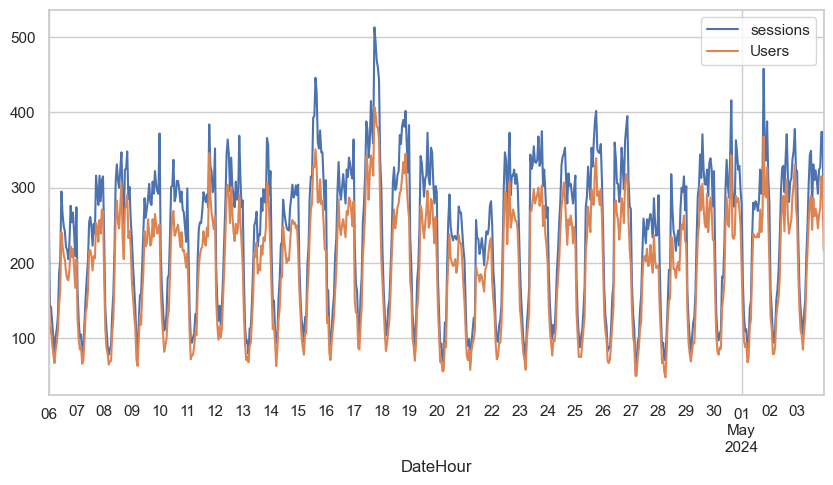

In [13]:
plt.figure(figsize=(10,5))
df.groupby("DateHour")[["sessions","Users"]].sum().plot(ax= plt.gca())
plt.show()

# 2.Which marketing channel brought the highest number of users to the website, and how can we use this insight to improve traffic from other sources?

In [14]:
df.head(1)

,channel group,DateHour,Users,sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count,hour
0,Direct,2024-04-16 23:00:00,237,300,144,47.526667,0.607595,4.673333,0.48,1402,23


In [15]:
df.groupby("channel group")["Users"].sum()

channel group
Direct            30042
Email                 2
Organic Search    28387
Organic Social    47572
Organic Video       123
Referral          26774
Unassigned          540
Name: Users, dtype: int64

C:\Users\HP\AppData\Local\Temp\ipykernel_11152\2557694304.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = df, x="channel group",y="Users", estimator = np.sum, palette = "viridis")


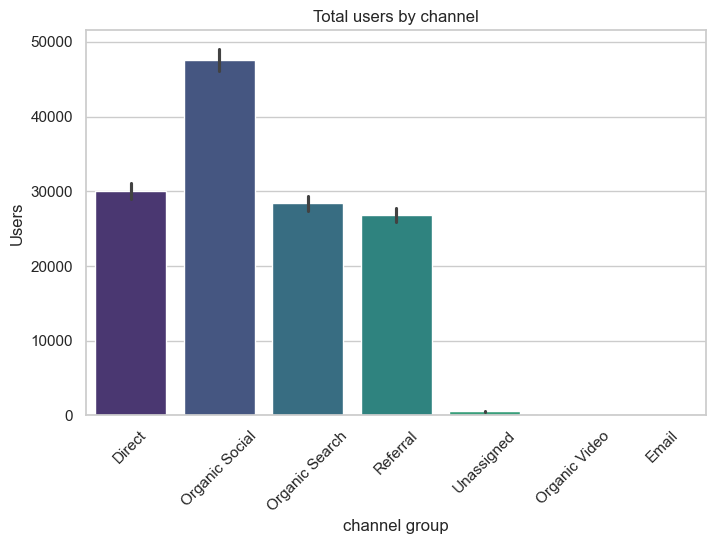

In [16]:
plt.figure(figsize=(8,5))
sns.barplot(data = df, x="channel group",y="Users", estimator = np.sum, palette = "viridis")
plt.title("Total users by channel")
plt.xticks(rotation = 45)
plt.show()

# 3. Which channel has the highest average engagement time, and what does that tell us about user behavior and content effectiveness?

In [17]:
df.head(1)

,channel group,DateHour,Users,sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count,hour
0,Direct,2024-04-16 23:00:00,237,300,144,47.526667,0.607595,4.673333,0.48,1402,23


In [18]:
df.groupby("channel group")["Average engagement time per session"].mean()

channel group
Direct             45.533104
Email              72.666667
Organic Search     47.005018
Organic Social     53.493681
Organic Video     180.360000
Referral           92.660842
Unassigned         78.957923
Name: Average engagement time per session, dtype: float64

C:\Users\HP\AppData\Local\Temp\ipykernel_11152\3883474505.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="channel group",y="Average engagement time per session",estimator=np.mean,palette="magma")


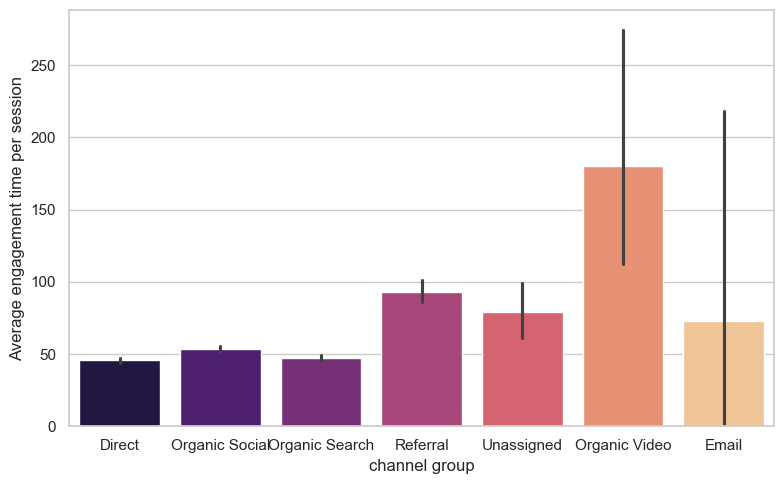

In [20]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="channel group",y="Average engagement time per session",estimator=np.mean,palette="magma")
plt.tight_layout()
plt.show()

# 4. How does engagement rate vary across different traffic channels?

In [21]:
df.head(1)

,channel group,DateHour,Users,sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count,hour
0,Direct,2024-04-16 23:00:00,237,300,144,47.526667,0.607595,4.673333,0.48,1402,23


C:\Users\HP\AppData\Local\Temp\ipykernel_11152\1200732647.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="channel group",y="Engagement rate",palette="magma")


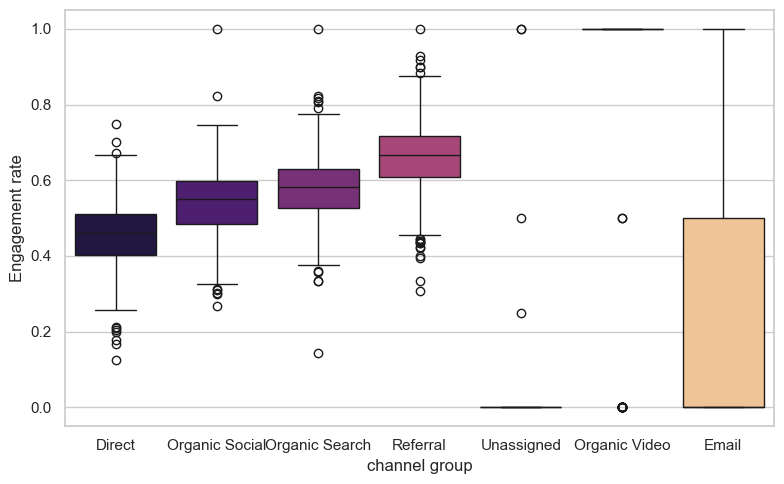

In [24]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="channel group",y="Engagement rate",palette="magma")
plt.tight_layout()
plt.show()

# 5. Which channels are driving more engaged sessions compared to non-engaged ones, and what strategies can improve engagement in underperforming channels?

In [26]:
df.head(1)

,channel group,DateHour,Users,sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count,hour
0,Direct,2024-04-16 23:00:00,237,300,144,47.526667,0.607595,4.673333,0.48,1402,23


In [27]:
session_df = df.groupby("channel group")[["sessions","Engaged sessions"]].sum().reset_index()

In [28]:
session_df

,channel group,sessions,Engaged sessions
0,Direct,37203,17243
1,Email,3,1
2,Organic Search,33372,19425
3,Organic Social,60627,32697
4,Organic Video,141,109
5,Referral,30990,20653
6,Unassigned,559,4


In [35]:
session_df["Non-Engaged"] =  session_df["sessions"] - session_df["Engaged sessions"]

In [36]:
session_df["Non-Engaged"]

0    19960
1        2
2    13947
3    27930
4       32
5    10337
6      555
Name: Non-Engaged, dtype: int64

In [37]:
session_df_melted = session_df.melt(id_vars="channel group",  value_vars=["Engaged sessions", "Non-Engaged"])


In [38]:
session_df_melted 

,channel group,variable,value
0,Direct,Engaged sessions,17243
1,Email,Engaged sessions,1
2,Organic Search,Engaged sessions,19425
3,Organic Social,Engaged sessions,32697
4,Organic Video,Engaged sessions,109
5,Referral,Engaged sessions,20653
6,Unassigned,Engaged sessions,4
7,Direct,Non-Engaged,19960
8,Email,Non-Engaged,2
9,Organic Search,Non-Engaged,13947


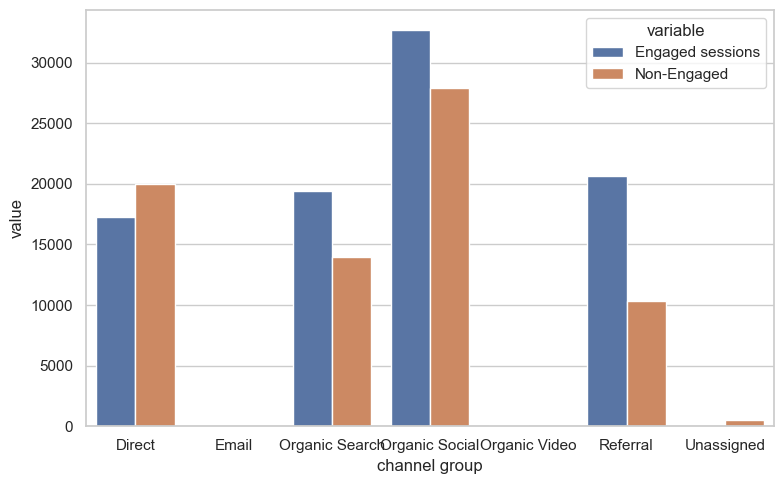

In [39]:
plt.figure(figsize=(8,5))
sns.barplot(data=session_df_melted, x="channel group",y="value",hue="variable")
plt.tight_layout()
plt.show()

# 6.At what hours of the day does each channel drive the most traffic?

In [40]:
df.head(1)


,channel group,DateHour,Users,sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count,hour
0,Direct,2024-04-16 23:00:00,237,300,144,47.526667,0.607595,4.673333,0.48,1402,23


In [42]:
heatmap_data = df.groupby(["hour","channel group"])["sessions"].sum().unstack().fillna(0)

In [43]:
heatmap_data 

channel group,Direct,Email,Organic Search,Organic Social,Organic Video,Referral,Unassigned
hour,,,,,,,
0,1684.0,0.0,1311.0,3917.0,6.0,1204.0,26.0
1,1196.0,0.0,984.0,2108.0,5.0,923.0,12.0
2,887.0,1.0,804.0,1537.0,2.0,755.0,13.0
3,771.0,0.0,606.0,1249.0,2.0,560.0,11.0
4,666.0,1.0,535.0,1081.0,2.0,495.0,6.0
5,679.0,0.0,506.0,951.0,1.0,453.0,8.0
6,768.0,0.0,639.0,1171.0,1.0,565.0,17.0
7,889.0,0.0,778.0,1524.0,2.0,743.0,10.0
8,1078.0,0.0,938.0,1886.0,4.0,862.0,13.0


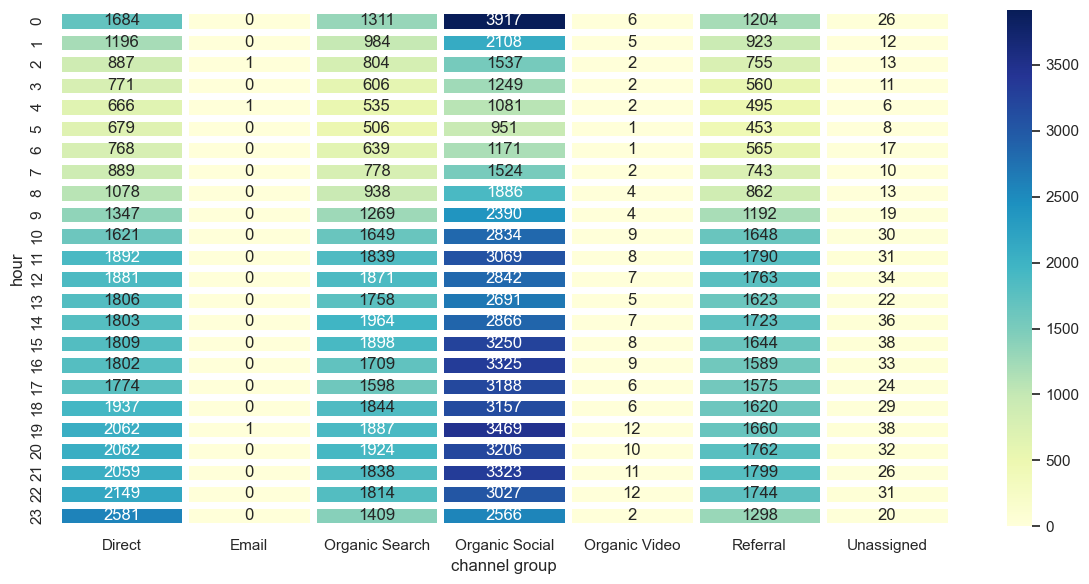

In [50]:
plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data , cmap="YlGnBu",linewidth=5, annot = True, fmt=".0f")
plt.tight_layout()
plt.show()

# 7. Is there any correlation between high traffic (sessions) and high engagement rate over time?

In [51]:
df.head(1)

,channel group,DateHour,Users,sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count,hour
0,Direct,2024-04-16 23:00:00,237,300,144,47.526667,0.607595,4.673333,0.48,1402,23


In [52]:
df_plot = df.groupby("DateHour")[["sessions","Engagement rate"]].mean().reset_index()

In [53]:
df_plot

,DateHour,sessions,Engagement rate
0,2024-04-06 00:00:00,54.000000,0.450262
1,2024-04-06 01:00:00,35.500000,0.489905
2,2024-04-06 02:00:00,35.500000,0.595759
3,2024-04-06 03:00:00,24.400000,0.446725
4,2024-04-06 04:00:00,25.500000,0.494964
...,...,...,...
667,2024-05-03 19:00:00,54.000000,0.498125
668,2024-05-03 20:00:00,54.500000,0.375790
669,2024-05-03 21:00:00,74.800000,0.471312
670,2024-05-03 22:00:00,62.333333,0.367749


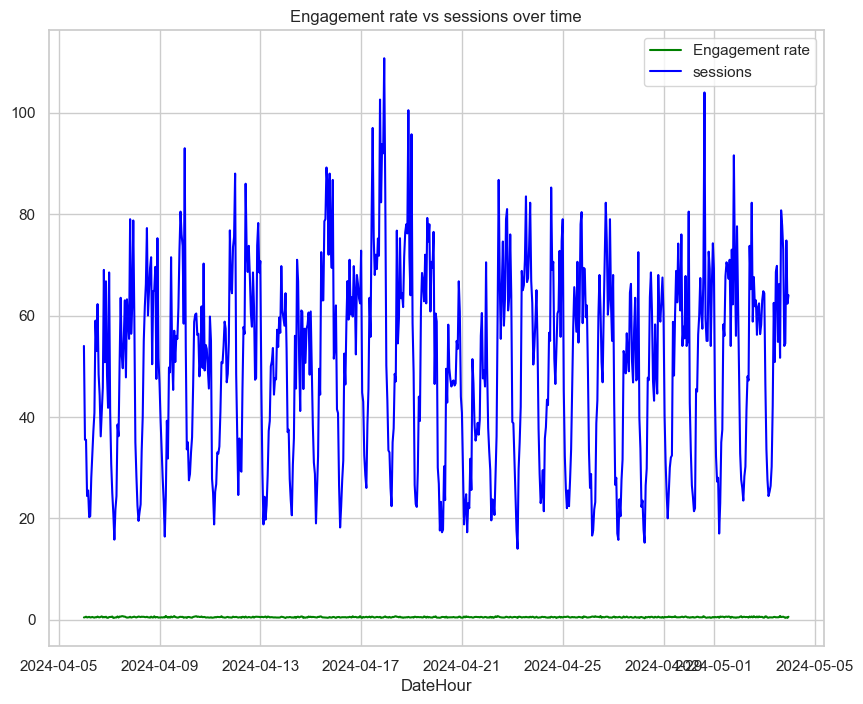

In [59]:
plt.figure(figsize=(10,8))
plt.plot(df_plot["DateHour"], df_plot["Engagement rate"], label = "Engagement rate",color = "green")
plt.plot(df_plot["DateHour"], df_plot["sessions"], label = "sessions",color = "blue")
plt.title("Engagement rate vs sessions over time")
plt.xlabel("DateHour")
plt.legend()
plt.grid(True)
plt.show()